# Buscando dados e armazenando em um dataframe

In [3]:
import pandas as pd

In [4]:
url = 'beijing_air_quality_ds.csv'

In [6]:
df = pd.read_csv(url)
df

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,1,2013,3,1,0,6.0,18.0,5.0,NaN,800.0,88.0,0.1,1021.1,-18.6,0.0,NW,4.4,Gucheng,2013-03-01 00:00:00
1,2,2013,3,1,1,6.0,15.0,5.0,NaN,800.0,88.0,-0.3,1021.5,-19.0,0.0,NW,4.0,Gucheng,2013-03-01 01:00:00
2,3,2013,3,1,2,5.0,18.0,NaN,NaN,700.0,52.0,-0.7,1021.5,-19.8,0.0,WNW,4.6,Gucheng,2013-03-01 02:00:00
3,4,2013,3,1,3,6.0,20.0,6.0,NaN,NaN,NaN,-1.0,1022.7,-21.2,0.0,W,2.8,Gucheng,2013-03-01 03:00:00
4,5,2013,3,1,4,5.0,17.0,5.0,NaN,600.0,73.0,-1.3,1023.0,-21.4,0.0,WNW,3.6,Gucheng,2013-03-01 04:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420763,35060,2017,2,28,19,27.0,72.0,8.0,92.0,800.0,16.0,10.3,1014.2,-12.4,0.0,W,1.8,Shunyi,2017-02-28 19:00:00
420764,35061,2017,2,28,20,47.0,55.0,17.0,86.0,1100.0,19.0,9.8,1014.5,-9.9,0.0,NW,1.5,Shunyi,2017-02-28 20:00:00
420765,35062,2017,2,28,21,18.0,28.0,4.0,30.0,500.0,64.0,9.1,1014.6,-12.7,0.0,NE,1.7,Shunyi,2017-02-28 21:00:00
420766,35063,2017,2,28,22,18.0,20.0,9.0,33.0,500.0,59.0,7.1,1015.2,-13.2,0.0,WNW,1.8,Shunyi,2017-02-28 22:00:00


# 1) Sanity Check

Vamos analisar os tipos das tabelas do dataframe

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 19 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   No        420768 non-null  int64  
 1   year      420768 non-null  int64  
 2   month     420768 non-null  int64  
 3   day       420768 non-null  int64  
 4   hour      420768 non-null  int64  
 5   PM2.5     412029 non-null  float64
 6   PM10      414319 non-null  float64
 7   SO2       411747 non-null  float64
 8   NO2       408652 non-null  float64
 9   CO        400067 non-null  float64
 10  O3        407491 non-null  float64
 11  TEMP      420370 non-null  float64
 12  PRES      420375 non-null  float64
 13  DEWP      420365 non-null  float64
 14  RAIN      420378 non-null  float64
 15  wd        418946 non-null  str    
 16  WSPM      420450 non-null  float64
 17  station   420768 non-null  str    
 18  datetime  420768 non-null  str    
dtypes: float64(11), int64(5), str(3)
memory usage: 61.0 MB


De inicio já é possível observar que todas as colunas estão com seus respectivos tipos com excessão da coluna datetime que está ainda como object

#### Analisando coluna de datetime

Vamos transformá-la para o tipo datetime

In [8]:
df['datetime'] = pd.to_datetime(df['datetime'])

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 19 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   No        420768 non-null  int64         
 1   year      420768 non-null  int64         
 2   month     420768 non-null  int64         
 3   day       420768 non-null  int64         
 4   hour      420768 non-null  int64         
 5   PM2.5     412029 non-null  float64       
 6   PM10      414319 non-null  float64       
 7   SO2       411747 non-null  float64       
 8   NO2       408652 non-null  float64       
 9   CO        400067 non-null  float64       
 10  O3        407491 non-null  float64       
 11  TEMP      420370 non-null  float64       
 12  PRES      420375 non-null  float64       
 13  DEWP      420365 non-null  float64       
 14  RAIN      420378 non-null  float64       
 15  wd        418946 non-null  str           
 16  WSPM      420450 non-null  float64       
 17  st

#### Excluindo colunas desnecessárias

Como as colunas ['day', 'month', 'year', 'hour'] foram utilizadas para gerar a coluna de datetime, podemos excluí-las. Tambem a coluna No pois não será considerada

In [10]:
df.drop(columns=['No','day','month','year','hour'], inplace=True)
df

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,6.0,18.0,5.0,NaN,800.0,88.0,0.1,1021.1,-18.6,0.0,NW,4.4,Gucheng,2013-03-01 00:00:00
1,6.0,15.0,5.0,NaN,800.0,88.0,-0.3,1021.5,-19.0,0.0,NW,4.0,Gucheng,2013-03-01 01:00:00
2,5.0,18.0,NaN,NaN,700.0,52.0,-0.7,1021.5,-19.8,0.0,WNW,4.6,Gucheng,2013-03-01 02:00:00
3,6.0,20.0,6.0,NaN,NaN,NaN,-1.0,1022.7,-21.2,0.0,W,2.8,Gucheng,2013-03-01 03:00:00
4,5.0,17.0,5.0,NaN,600.0,73.0,-1.3,1023.0,-21.4,0.0,WNW,3.6,Gucheng,2013-03-01 04:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420763,27.0,72.0,8.0,92.0,800.0,16.0,10.3,1014.2,-12.4,0.0,W,1.8,Shunyi,2017-02-28 19:00:00
420764,47.0,55.0,17.0,86.0,1100.0,19.0,9.8,1014.5,-9.9,0.0,NW,1.5,Shunyi,2017-02-28 20:00:00
420765,18.0,28.0,4.0,30.0,500.0,64.0,9.1,1014.6,-12.7,0.0,NE,1.7,Shunyi,2017-02-28 21:00:00
420766,18.0,20.0,9.0,33.0,500.0,59.0,7.1,1015.2,-13.2,0.0,WNW,1.8,Shunyi,2017-02-28 22:00:00


In [12]:
df.rename(columns={'wd': 'WD', 'station': 'Station','datetime':'Datetime'}, inplace=True)
df.head()

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WD,WSPM,Station,Datetime
0,6.0,18.0,5.0,NaN,800.0,88.0,0.1,1021.1,-18.6,0.0,NW,4.4,Gucheng,2013-03-01 00:00:00
1,6.0,15.0,5.0,NaN,800.0,88.0,-0.3,1021.5,-19.0,0.0,NW,4.0,Gucheng,2013-03-01 01:00:00
2,5.0,18.0,NaN,NaN,700.0,52.0,-0.7,1021.5,-19.8,0.0,WNW,4.6,Gucheng,2013-03-01 02:00:00
3,6.0,20.0,6.0,NaN,NaN,NaN,-1.0,1022.7,-21.2,0.0,W,2.8,Gucheng,2013-03-01 03:00:00
4,5.0,17.0,5.0,NaN,600.0,73.0,-1.3,1023.0,-21.4,0.0,WNW,3.6,Gucheng,2013-03-01 04:00:00


#### Verificando e removendo possíveis duplicatas

In [13]:
# Verificando duplicatas

total_duplicates = df.duplicated().sum()
total_duplicates

np.int64(0)

Como não encontramos duplicatas, podemos prosseguir

#### Ordenando dataframe e redefinindo os indices

Vamos ordenar os valores de acordo com a coluna 'station' e 'datetime' já que os dados vão seguir um padrão de acordo com a estação medida.
<br>
Para termos mais organização do dataframe vamos redefinir os index

In [14]:
df_sorted = df.sort_values(by=['Station','Datetime'])
df_sorted.reset_index(drop=True, inplace=True)
df_sorted

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WD,WSPM,Station,Datetime
0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01 00:00:00
1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,2013-03-01 01:00:00
2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2013-03-01 02:00:00
3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,2013-03-01 03:00:00
4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,2013-03-01 04:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420763,11.0,32.0,3.0,24.0,400.0,72.0,12.5,1013.5,-16.2,0.0,NW,2.4,Wanshouxigong,2017-02-28 19:00:00
420764,13.0,32.0,3.0,41.0,500.0,50.0,11.6,1013.6,-15.1,0.0,WNW,0.9,Wanshouxigong,2017-02-28 20:00:00
420765,14.0,28.0,4.0,38.0,500.0,54.0,10.8,1014.2,-13.3,0.0,NW,1.1,Wanshouxigong,2017-02-28 21:00:00
420766,12.0,23.0,4.0,30.0,400.0,59.0,10.5,1014.4,-12.9,0.0,NNW,1.2,Wanshouxigong,2017-02-28 22:00:00


#### Tratamento de valores nulos

Vamos agora verificar e tratar os valores nulos da base de dados
<br>
Primeiramente verificar se existem valores nulos e quantos são em cada coluna

In [15]:
df_sorted.isna().sum()

PM2.5        8739
PM10         6449
SO2          9021
NO2         12116
CO          20701
O3          13277
TEMP          398
PRES          393
DEWP          403
RAIN          390
WD           1822
WSPM          318
Station         0
Datetime        0
dtype: int64

Podemos ver que a coluna datetime e station, não possuem nulos, o que é bom já que sabemos que as amostras são medições horárias.
<br>
Já para as outras variáveis, poderiamos remover seus registros nulos já que a proporção é bem pequena em relação ao total de amostras.
<br>
Porém, como estamos tratando de medições horárias e são dados que mudam de forma gradual, podemos tratar esses valores com a interpolação linear

In [17]:
# Selecionando as colunas numéricas para interpolacao
numeric_columns = ['PM2.5','PM10','SO2','NO2','CO','O3','TEMP','PRES','DEWP','RAIN','WSPM']

# Vamos interpolar utilizando o agrupamento para que o algoritmo nao "misture" o final de uma estacao com o inicio de outra
df_sorted[numeric_columns] = df_sorted.groupby('Station', observed=True)[numeric_columns].transform(lambda x: x.interpolate(method='linear'))

Vamos observar agora se ainda existem nulos no dataframe

In [18]:
df_sorted.isna().sum()

PM2.5          0
PM10           0
SO2            0
NO2           22
CO             0
O3             0
TEMP           0
PRES           0
DEWP           0
RAIN           0
WD          1822
WSPM           0
Station        0
Datetime       0
dtype: int64

Podemos ver que ainda existem nulos na coluna 'NO2'. Vamos verificar quais sao esses registros

In [19]:
no2_null = df_sorted[df_sorted['NO2'].isna()]
no2_null

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WD,WSPM,Station,Datetime
70128,4.0,4.0,3.0,NaN,200.0,82.0,-2.3,1020.8,-19.7,0.0,E,0.5,Dingling,2013-03-01 00:00:00
70129,7.0,7.0,3.0,NaN,200.0,80.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Dingling,2013-03-01 01:00:00
175320,6.0,18.0,5.0,NaN,800.0,88.0,0.1,1021.1,-18.6,0.0,NW,4.4,Gucheng,2013-03-01 00:00:00
175321,6.0,15.0,5.0,NaN,800.0,88.0,-0.3,1021.5,-19.0,0.0,NW,4.0,Gucheng,2013-03-01 01:00:00
175322,5.0,18.0,5.5,NaN,700.0,52.0,-0.7,1021.5,-19.8,0.0,WNW,4.6,Gucheng,2013-03-01 02:00:00
175323,6.0,20.0,6.0,NaN,650.0,62.5,-1.0,1022.7,-21.2,0.0,W,2.8,Gucheng,2013-03-01 03:00:00
175324,5.0,17.0,5.0,NaN,600.0,73.0,-1.3,1023.0,-21.4,0.0,WNW,3.6,Gucheng,2013-03-01 04:00:00
175325,4.0,11.0,3.0,NaN,700.0,87.0,-1.8,1023.6,-21.9,0.0,E,1.2,Gucheng,2013-03-01 05:00:00
175326,3.0,6.0,3.0,NaN,700.0,92.0,-2.6,1024.3,-20.4,0.0,ENE,1.2,Gucheng,2013-03-01 06:00:00
175327,5.0,5.0,3.0,NaN,800.0,86.0,-0.9,1025.6,-20.5,0.0,ENE,1.1,Gucheng,2013-03-01 07:00:00


Buscando as janelas em que deram esses nulos

In [20]:
df_sorted[70125:70132]

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WD,WSPM,Station,Datetime
70125,7.0,23.0,5.0,17.000000,500.0,68.0,9.5,1009.4,-13.0,0.0,N,1.5,Changping,2017-02-28 21:00:00
70126,11.0,20.0,3.0,15.000000,500.0,72.0,7.8,1009.6,-12.6,0.0,NW,1.4,Changping,2017-02-28 22:00:00
70127,20.0,25.0,6.0,28.000000,900.0,54.0,7.0,1009.4,-12.2,0.0,N,1.9,Changping,2017-02-28 23:00:00
70128,4.0,4.0,3.0,NaN,200.0,82.0,-2.3,1020.8,-19.7,0.0,E,0.5,Dingling,2013-03-01 00:00:00
70129,7.0,7.0,3.0,NaN,200.0,80.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Dingling,2013-03-01 01:00:00
70130,5.0,5.0,3.0,2.000000,200.0,79.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Dingling,2013-03-01 02:00:00
70131,6.0,6.0,3.0,2.666667,200.0,79.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Dingling,2013-03-01 03:00:00


In [21]:
df_sorted[175315:175323]

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WD,WSPM,Station,Datetime
175315,13.0,37.0,3.0,36.0,400.0,60.0,12.5,1013.5,-16.2,0.0,NW,2.4,Guanyuan,2017-02-28 19:00:00
175316,20.0,43.0,4.0,48.0,500.0,43.0,11.6,1013.6,-15.1,0.0,WNW,0.9,Guanyuan,2017-02-28 20:00:00
175317,16.0,33.0,5.0,39.0,500.0,50.0,10.8,1014.2,-13.3,0.0,NW,1.1,Guanyuan,2017-02-28 21:00:00
175318,11.0,24.0,5.0,47.0,500.0,41.0,10.5,1014.4,-12.9,0.0,NNW,1.2,Guanyuan,2017-02-28 22:00:00
175319,15.0,27.0,5.0,53.0,600.0,33.0,8.6,1014.1,-15.9,0.0,NNE,1.3,Guanyuan,2017-02-28 23:00:00
175320,6.0,18.0,5.0,NaN,800.0,88.0,0.1,1021.1,-18.6,0.0,NW,4.4,Gucheng,2013-03-01 00:00:00
175321,6.0,15.0,5.0,NaN,800.0,88.0,-0.3,1021.5,-19.0,0.0,NW,4.0,Gucheng,2013-03-01 01:00:00
175322,5.0,18.0,5.5,NaN,700.0,52.0,-0.7,1021.5,-19.8,0.0,WNW,4.6,Gucheng,2013-03-01 02:00:00


In [22]:
df_sorted[175337:175343]

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WD,WSPM,Station,Datetime
175337,10.0,20.0,4.0,NaN,800.0,87.0,5.1,1024.2,-18.7,0.0,WNW,1.0,Gucheng,2013-03-01 17:00:00
175338,11.0,20.0,6.0,NaN,900.0,80.0,3.7,1025.3,-19.2,0.0,E,1.6,Gucheng,2013-03-01 18:00:00
175339,11.0,31.0,8.0,NaN,1000.0,69.0,2.7,1026.1,-19.3,0.0,E,1.7,Gucheng,2013-03-01 19:00:00
175340,13.0,25.0,12.0,5.0,1100.0,61.0,1.6,1027.1,-18.4,0.0,ESE,1.9,Gucheng,2013-03-01 20:00:00
175341,15.0,23.0,14.0,13.0,1200.0,52.0,1.0,1028.1,-17.4,0.0,SSE,0.7,Gucheng,2013-03-01 21:00:00
175342,16.0,28.0,16.0,19.0,1200.0,45.0,1.3,1028.4,-17.6,0.0,E,1.0,Gucheng,2013-03-01 22:00:00


Podemos ver que esses problemas foram de inicio de medicao da estacao

Para corrigi-los, vamos subsituí-los com a média da estação/horário

In [24]:
df_sorted['NO2'] = df_sorted['NO2'].fillna(df_sorted.groupby('Station')['NO2'].transform('mean'))

Vamos verificar se ainda temos valores nulos

In [25]:
df_sorted.isna().sum()

PM2.5          0
PM10           0
SO2            0
NO2            0
CO             0
O3             0
TEMP           0
PRES           0
DEWP           0
RAIN           0
WD          1822
WSPM           0
Station        0
Datetime       0
dtype: int64

Como só temos nulos na coluna 'wd', vamos tratá-los preenchendo com a moda (valor mais frequente) naquela estação e horário

In [26]:
df_sorted['WD'] = df_sorted.groupby('Station', observed=True)['WD'].transform(lambda x: x.fillna(x.mode()[0]))

Agora verificar se esses nulos foram corrigidos

In [27]:
df_sorted.isna().sum()

PM2.5       0
PM10        0
SO2         0
NO2         0
CO          0
O3          0
TEMP        0
PRES        0
DEWP        0
RAIN        0
WD          0
WSPM        0
Station     0
Datetime    0
dtype: int64

#### Colunas categóricas

As colunas 'wd' (direção do vento) e 'station' (estação de monitoramento) estão como object.
<br>
Por questão de otimização de espaço e processamento, vamos transformar essas colunas para o tipo category.
<br>

In [28]:
if 'Station' in df_sorted.columns:
    df_sorted['Station'] = df_sorted['Station'].astype('category')

if 'wd' in df_sorted.columns:
    df_sorted['WD'] = df_sorted['WD'].astype('category')

In [29]:
df_sorted.info()

<class 'pandas.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 14 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   PM2.5     420768 non-null  float64       
 1   PM10      420768 non-null  float64       
 2   SO2       420768 non-null  float64       
 3   NO2       420768 non-null  float64       
 4   CO        420768 non-null  float64       
 5   O3        420768 non-null  float64       
 6   TEMP      420768 non-null  float64       
 7   PRES      420768 non-null  float64       
 8   DEWP      420768 non-null  float64       
 9   RAIN      420768 non-null  float64       
 10  WD        420768 non-null  str           
 11  WSPM      420768 non-null  float64       
 12  Station   420768 non-null  category      
 13  Datetime  420768 non-null  datetime64[us]
dtypes: category(1), datetime64[us](1), float64(11), str(1)
memory usage: 42.1 MB


### Agora estamos prontos para análise exploratória

# 2) Análise exploratória

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


### Vamos analisar o comportamento do MP2.5 nos seguintes pontos
- Sazonalidade Temporal (Tendência ao longo do tempo)
- Comportamento por Hora do Dia (Ciclo Diário)
- Matriz de Correlação
- Impacto das Condições Climáticas

#### Sazonalidade Temporal (Tendência ao longo do tempo)
<strong>Objetivo</strong>: Gráfico de linha da média do MP2.5 ao longo dos anos ou meses para verificar se há épocas do ano específicas em que a poluição aumenta drasticamente

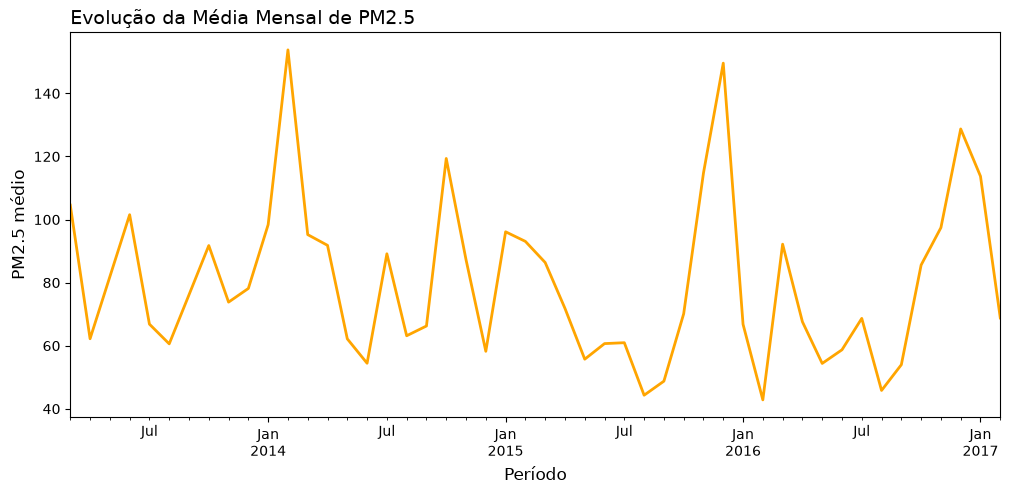

In [32]:
# Criando coluna de ano-mes para facilitar a visualicao
df_sorted['year_month'] = df_sorted['Datetime'].dt.to_period('M').dt.to_timestamp()

plt.figure(figsize=(12,5))
year_month_mean = df_sorted.groupby('year_month')['PM2.5'].mean()
year_month_mean.plot(color='orange', linewidth=2)
plt.title('Evolução da Média Mensal de PM2.5', fontsize=14, loc='left')
plt.xlabel('Período', fontsize=12)
plt.ylabel('PM2.5 médio', fontsize=12)

plt.show()

O gráfico mostra forte sazonalidade, atingido seu pico no período de inverno (Dezembro a Fevereiro), com médias superando os 120 $\mu g/m^3$
<br>
Além disso, mostra também quedas durante o verão chegando a médias abaixo dos 60 $\mu g/m^3$

#### Comportamento por Hora do Dia (Ciclo Diário)
<strong>Objetivo</strong>: Gráfico de linha agrupado por hora para evidenciar picos de poluição nos horários de pico de trânsito

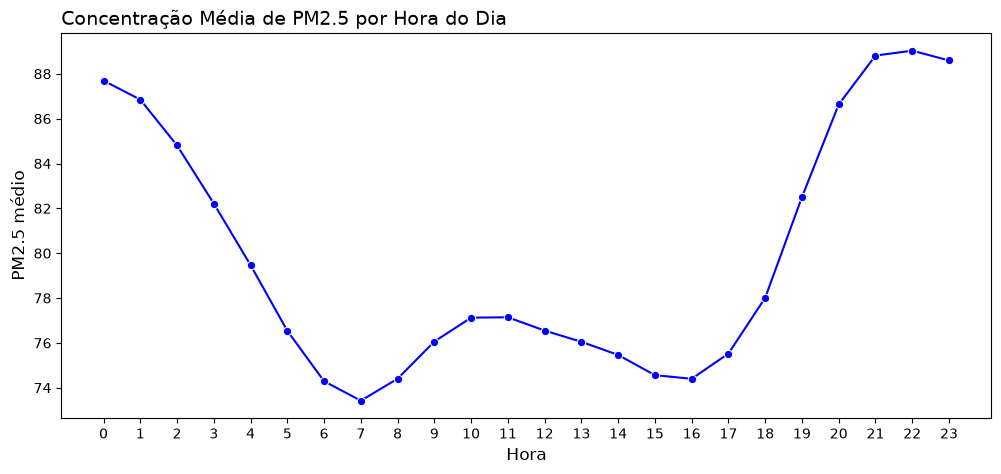

In [33]:
plt.figure(figsize=(12,5))
sns.lineplot(data=df_sorted, x=df_sorted['Datetime'].dt.hour, y='PM2.5', errorbar=None, marker='o', color='blue')
plt.title('Concentração Média de PM2.5 por Hora do Dia', fontsize=14, loc='left')
plt.xlabel('Hora', fontsize=12)
plt.ylabel('PM2.5 médio', fontsize=12)
plt.xticks(range(0,24))

plt.show()

O gráfico mostra um padrão diário interessante onde podemos observar uma maior concentração durante o período noturno chegando a média de <br>
90 $\mu g/mˆ3$. Uma queda no decorrer da madruga chegando a uma média mínima matutina de 70 $\mu g/mˆ3$. Um leve crescimento vespertino e <br>
acelera fortemente após as 18h, transitando para noite

Podemos ter como Insigths e Hipóteses os seguintes pontos:

- O pico noturno e o início da madrigada podem estar associados à diminuição da altura da camada limite planetária e à formação dass inversões térmicas noturnas fazendo com que os poluentes fiquem "presos" mais perto da superfície, acumulando na atmosfera.
- Limpeza Matinal: o início do aquecimento solar logo ao amanhecer, pode "agitar" as moléculas da atmosfera, facilitando a dispersão desses poluentes, antes das emissões <br> diárias causadas pela ação humana e tráfego de veículos

#### Matriz de Correlação
<strong>Objetivo</strong>: Um mapa de calor de correlação de Pearson entre o PM2.5 e as demais variáveis numéricas, para ver <br>o que mais influencia a concentração de material particulado



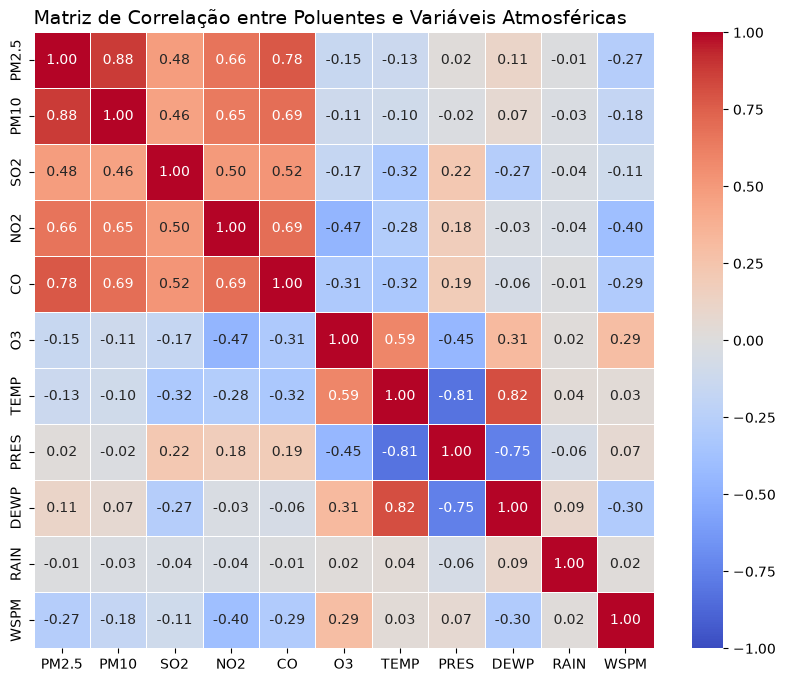

In [34]:
plt.figure(figsize=(10,8))
columns_corr = numeric_columns
matrix_corr = df_sorted[columns_corr].corr()

sns.heatmap(matrix_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidth=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlação entre Poluentes e Variáveis Atmosféricas', fontsize=14, loc='left')

plt.show()

A matriz nos mostra:

- Forte correlação entre poluentes: positiva com PM10 (0.88), CO (0.78) e NO2 (0.66), apontando fontes de emissão comuns em combustíveis
- Dispersão por Vento: velocidade do vento (WSPM) com correlação negativa (-0.27), indicando seu papel na dispersão do PM2.5
- Forte correlação positiva entre temperatura e ponto de orvalho (0.82) e forte correlação negativa da pressão atmosférica (-0.81)

#### Impacto das Condições Climáticas
<strong>Objetivo</strong>: Gráficos de dispersão relacionando o PM2.5 com a valocidade do vento (WSPM) e precipitação (RAIN), buscando demonstrar visualmente <br>
como os ventos mais fortes e chuvas ajudam e dispersar o poluente e "limpar" o ar.



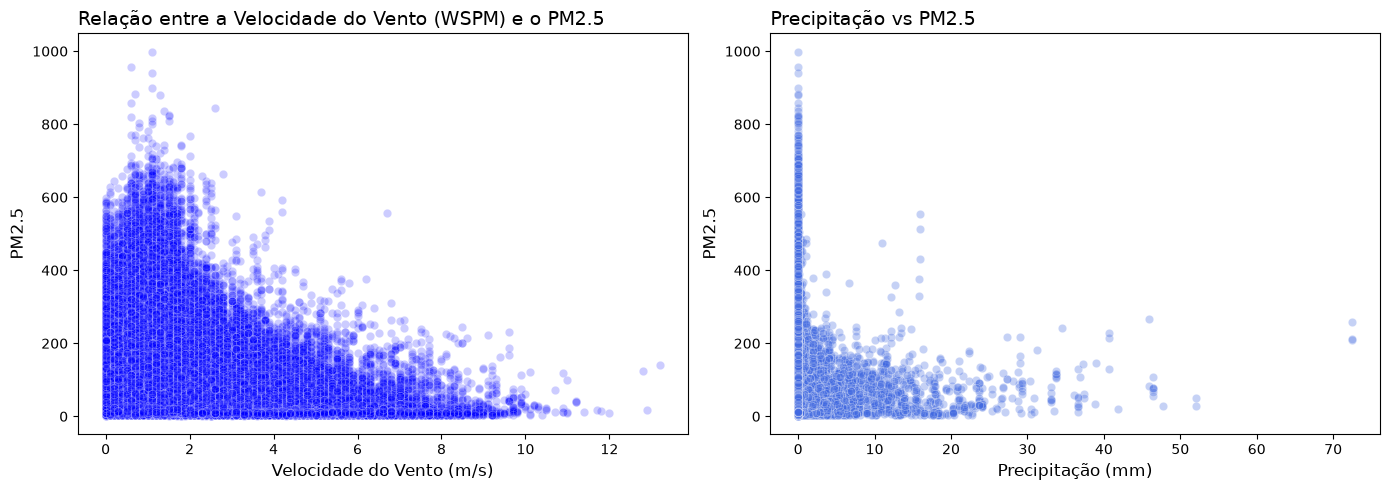

In [35]:
fig, axes = plt.subplots(1,2,figsize=(14,5))

# Grafico 1: velocidade do vento (WSPM) vs PM2.5
sns.scatterplot(data=df_sorted, x='WSPM', y='PM2.5', alpha=0.2, color='blue', ax=axes[0])
axes[0].set_title('Relação entre a Velocidade do Vento (WSPM) e o PM2.5', fontsize=14, loc='left')
axes[0].set_xlabel('Velocidade do Vento (m/s)', fontsize=12)
axes[0].set_ylabel('PM2.5', fontsize=12)

# Grafico 2: chuva (RAIN) vs PM2.5
sns.scatterplot(data=df_sorted, x='RAIN', y='PM2.5', alpha=0.3, color='royalblue',ax=axes[1])
axes[1].set_title('Precipitação vs PM2.5', fontsize=14, loc='left')
axes[1].set_xlabel('Precipitação (mm)', fontsize=12)
axes[1].set_ylabel('PM2.5', fontsize=12)

plt.tight_layout()
plt.show()

Os dois gráficos de dispersão revelam como os fatores meteorológicos atuam de maneiras distintas na limpeza e retenção de material particulado na atmosfera:

- Decaimento inverso onde pode-se observar maior concentração do PM2.5 quando os ventos estão mais fracos com PM2.5 atingindo seu patamar de 1000 $\mu g/mˆ3$
- A medida que a força do vento aumenta, a dispersão do material particulado aumenta e sua concentração diminui
- Concentração em dias secos com imensa maioria agrupando-se com a precipitação em 0 mm. Mostra que a base de dados de composta, em sua maioria, por dias mais secos.
- Efeito de "Lavagem" (Scavenging) mostrando que quando chove, mostra que os níveis altos de PM2.5 desaparecem quase por completo

# 3) Conclusões

### Qualidade Geral dos Dados

O conjunto de dados demonstrou alta robustez com mais de 420 mil registros horários, mas exigiu um tratamento estruturado devido a lacunas em variáveis de poluentes e meteorológicas.

A aplicação de interpolação linear agrupada por estação preservou a continuidade física dos dados. Os nulos residuais foram corrigidos com preenchimento direcional (ffill/bfill) resultando em uma base limpa e consitente para análise.

### Principais achados da Análise Exploratória

- Forte Sazonalidade Anual: a concentração de PM2.5 exibe um ciclo sazonal acentuado, tendo picos severos durante o inverno (Dezembro a Fevereiro) e quedas na metade do ano
- Ciclo Diário Definido: a concentração atinge patamares máximos durante a noite, provavelmente pela estabilidade atmosférica, e ponto minimo nas primeiras horas da manhã
- Forte Correlação entre Poluentes: correlação altíssima entre poluentes como o PM10 (0.88) e o CO (0.78), indicando fontes de emissão comuns, além de avidenciar o forte impacto de agentes naturais como velocidade do vento (WSPM) e precipitação (RAIN) que inibe episódios críticas de poluição

### Próximos Passos:

- Tratamento de Variáveis Categóricas: Aplicar técnicas de One-Hot Encoding na direção do vento (wd) e otimizar o uso da variável de estação de monitoramento
- Modelagem Preditiva: Construir, treinar e comparar modelos de Machine Learning para prever as concentrações futuras de PM2.5